--- ข้อมูลหลังจากการเตรียม Features ---
   face_width  face_height  face_area        age
0         197          344      67768  25.450744
1         409          317     129653  24.985441
2         103          176      18128  24.032164
3         372          289     107508  32.322309
4         137          106      14522  19.465068

=== Running: Simple Linear Regression ===
Coefficient: 0.0000, Intercept: 20.0801
Simple LR - R² Score: 0.4109, MSE: 23.6207, MAE: 3.8733

=== Running: Multiple Linear Regression ===
Multiple LR - R² Score: 0.3739, MSE: 25.1057, MAE: 4.0986

=== Running: PCA & Regression ===
PCA LR - R² Score: 0.4443, MSE: 22.2815, MAE: 3.8617


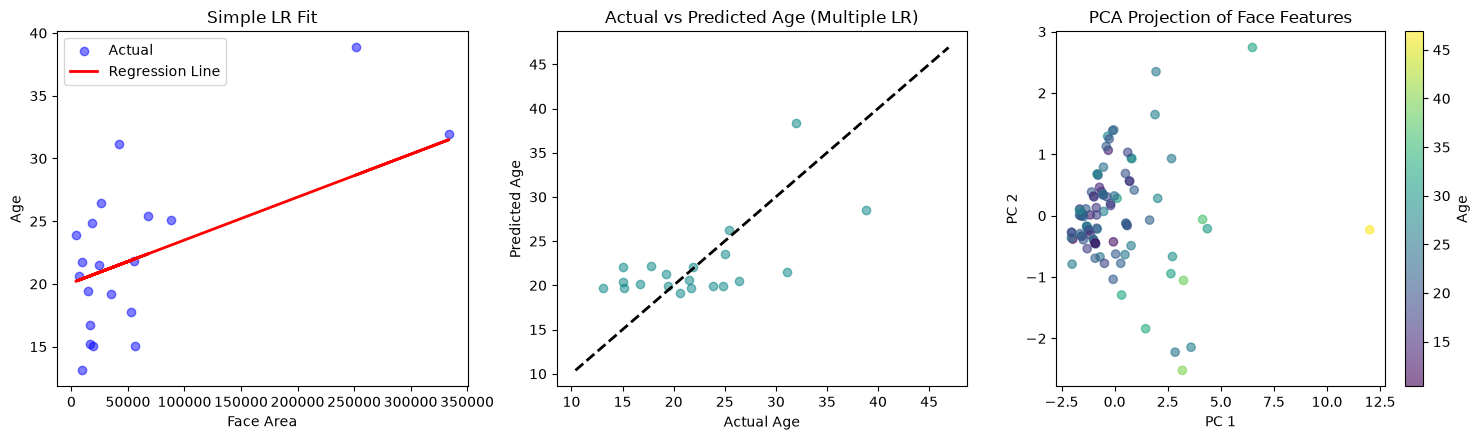


=== LAB 1 Summary Table ===
                     Model  R2 Score       MSE      MAE
  Simple Linear Regression  0.410918 23.620719 3.873253
Multiple Linear Regression  0.373885 25.105672 4.098620
     PCA Linear Regression  0.444316 22.281534 3.861719


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. โหลดข้อมูล
df = pd.read_csv('faces.csv')

# 2. ทำวิศวกรรมข้อมูล (Feature Engineering)
df['face_width'] = df['x1'] - df['x0']
df['face_height'] = df['y1'] - df['y0']
df['face_area'] = df['face_width'] * df['face_height']

# จำลองตัวแปรเป้าหมาย Age สำหรับทำ Regression
np.random.seed(42)
df['age'] = 20 + (df['face_area'] / df['face_area'].max()) * 40 + np.random.normal(0, 5, size=len(df))

print("--- ข้อมูลหลังจากการเตรียม Features ---")
print(df[['face_width', 'face_height', 'face_area', 'age']].head())

# ==========================================
# 🛑 PART 1: Simple Linear Regression
# ==========================================
print("\n=== Running: Simple Linear Regression ===")
X_simple = df[['face_area']]  # 1 Feature
y = df['age']

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_simple, y, test_size=0.2, random_state=42)

simple_model = LinearRegression()
simple_model.fit(X_train_s, y_train_s)
y_pred_s = simple_model.predict(X_test_s)

s_r2 = r2_score(y_test_s, y_pred_s)
s_mse = mean_squared_error(y_test_s, y_pred_s)
s_mae = mean_absolute_error(y_test_s, y_pred_s)

print(f"Coefficient: {simple_model.coef_[0]:.4f}, Intercept: {simple_model.intercept_:.4f}")
print(f"Simple LR - R² Score: {s_r2:.4f}, MSE: {s_mse:.4f}, MAE: {s_mae:.4f}")

# ==========================================
# 🛑 PART 2: Multiple Linear Regression
# ==========================================
print("\n=== Running: Multiple Linear Regression ===")
X_multi = df[['width', 'height', 'face_width', 'face_height', 'face_area']]

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_multi, y, test_size=0.2, random_state=42)

multi_model = LinearRegression()
multi_model.fit(X_train_m, y_train_m)
y_pred_m = multi_model.predict(X_test_m)

m_r2 = r2_score(y_test_m, y_pred_m)
m_mse = mean_squared_error(y_test_m, y_pred_m)
m_mae = mean_absolute_error(y_test_m, y_pred_m)

print(f"Multiple LR - R² Score: {m_r2:.4f}, MSE: {m_mse:.4f}, MAE: {m_mae:.4f}")

# ==========================================
# 🛑 PART 3: Dimensionality Reduction using PCA
# ==========================================
print("\n=== Running: PCA & Regression ===")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_multi)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(X_pca, y, test_size=0.2, random_state=42)

pca_model = LinearRegression()
pca_model.fit(X_train_p, y_train_p)
y_pred_p = pca_model.predict(X_test_p)

p_r2 = r2_score(y_test_p, y_pred_p)
p_mse = mean_squared_error(y_test_p, y_pred_p)
p_mae = mean_absolute_error(y_test_p, y_pred_p)

print(f"PCA LR - R² Score: {p_r2:.4f}, MSE: {p_mse:.4f}, MAE: {p_mae:.4f}")

# ==========================================
# 📊 PART 4: Data Visualization & Summary
# ==========================================
plt.figure(figsize=(15, 4.5))

# 1. Simple Linear Regression Line
plt.subplot(1, 3, 1)
plt.scatter(X_test_s, y_test_s, color='blue', alpha=0.5, label='Actual')
plt.plot(X_test_s, y_pred_s, color='red', linewidth=2, label='Regression Line')
plt.xlabel('Face Area')
plt.ylabel('Age')
plt.title('Simple LR Fit')
plt.legend()

# 2. Actual vs Predicted Age (Multiple LR)
plt.subplot(1, 3, 2)
plt.scatter(y_test_m, y_pred_m, alpha=0.5, color='teal')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
plt.xlabel('Actual Age')
plt.ylabel('Predicted Age')
plt.title('Actual vs Predicted Age (Multiple LR)')

# 3. PCA Projection
plt.subplot(1, 3, 3)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['age'], cmap='viridis', alpha=0.6)
plt.colorbar(label='Age')
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.title('PCA Projection of Face Features')

plt.tight_layout()
plt.show()

# สรุปผลการเปรียบเทียบในรูปแบบตาราง DataFrame
summary_df = pd.DataFrame({
    'Model': ['Simple Linear Regression', 'Multiple Linear Regression', 'PCA Linear Regression'],
    'R2 Score': [s_r2, m_r2, p_r2],
    'MSE': [s_mse, m_mse, p_mse],
    'MAE': [s_mae, m_mae, p_mae]
})

print("\n=== LAB 1 Summary Table ===")
print(summary_df.to_string(index=False))

=== Classification Results (Logistic Regression) ===
Accuracy:  0.9000
Precision: 0.8889
Recall:    1.0000
F1-Score:  0.9412


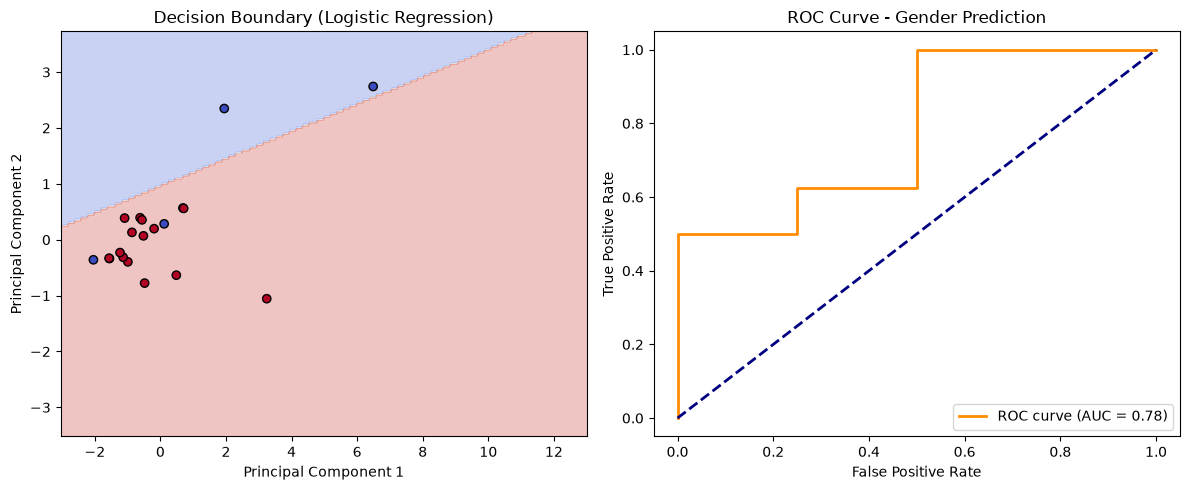

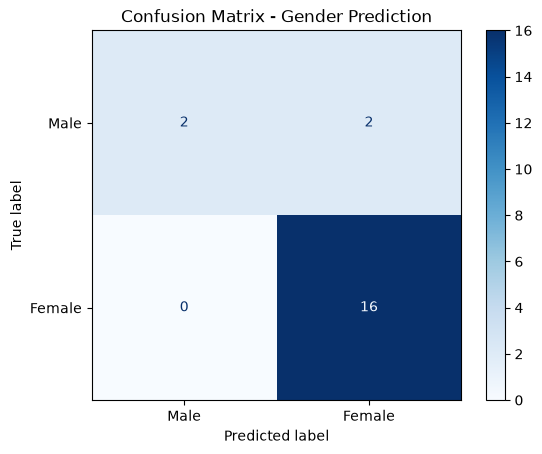

In [4]:
# ==========================================
# 🛑 LAB 2: Classification & Gender Prediction
# ==========================================
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

# 1. จำลองข้อมูลเป้าหมาย Gender (0 = Male, 1 = Female) สำหรับทำ Classification
np.random.seed(42)
df['gender'] = (df['face_width'] / df['face_height'] > 1.0).astype(int)
y_gender = df['gender']

# 2. แบ่งข้อมูล Training และ Testing Sets (ใช้ X_pca จาก LAB 1)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_pca, y_gender, test_size=0.2, random_state=42)

# 3. สร้างและฝึกสอน Logistic Regression Model
clf = LogisticRegression()
clf.fit(X_train_c, y_train_c)

y_pred_c = clf.predict(X_test_c)
y_prob_c = clf.predict_proba(X_test_c)[:, 1]

# 4. คำนวณตัวชี้วัดประสิทธิภาพ
acc = accuracy_score(y_test_c, y_pred_c)
prec = precision_score(y_test_c, y_pred_c)
rec = recall_score(y_test_c, y_pred_c)
f1 = f1_score(y_test_c, y_pred_c)

print("=== Classification Results (Logistic Regression) ===")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-Score:  {f1:.4f}")

# 5. แสดงภาพ Decision Boundary และ ROC Curve
plt.figure(figsize=(12, 5))

# Plot 1: Decision Boundary Visualization
plt.subplot(1, 2, 1)
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                     np.arange(y_min, y_max, 0.05))

Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
plt.scatter(X_test_c[:, 0], X_test_c[:, 1], c=y_test_c, cmap=plt.cm.coolwarm, edgecolors='k')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Decision Boundary (Logistic Regression)')

# Plot 2: ROC Curve
plt.subplot(1, 2, 2)
fpr, tpr, _ = roc_curve(y_test_c, y_prob_c)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Gender Prediction')
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

# 6. แสดง Confusion Matrix
cm = confusion_matrix(y_test_c, y_pred_c)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Male', 'Female'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Gender Prediction")
plt.show()

In [5]:
# ==========================================
# 🛑 LAB 3: Model Comparison & Performance Evaluation
# ==========================================

# 1. เปรียบเทียบ Training vs Testing Performance (Regression)
train_r2_s = r2_score(y_train_s, simple_model.predict(X_train_s))
train_r2_m = r2_score(y_train_m, multi_model.predict(X_train_m))
train_r2_p = r2_score(y_train_p, pca_model.predict(X_train_p))

reg_comp_df = pd.DataFrame({
    'Model': ['Simple Linear Regression', 'Multiple Linear Regression', 'PCA Linear Regression'],
    'Train R²': [train_r2_s, train_r2_m, train_r2_p],
    'Test R²': [s_r2, m_r2, p_r2],
    'Test MSE': [s_mse, m_mse, p_mse]
})

print("\n=== LAB 3.1: Regression Model Performance Comparison ===")
print(reg_comp_df.to_string(index=False))

# 2. เปรียบเทียบ Training vs Testing Performance (Classification)
train_acc_c = accuracy_score(y_train_c, clf.predict(X_train_c))

clf_comp_df = pd.DataFrame({
    'Model': ['Logistic Regression (Gender Prediction)'],
    'Train Accuracy': [train_acc_c],
    'Test Accuracy': [acc],
    'Test Precision': [prec],
    'Test Recall': [rec],
    'Test F1-Score': [f1],
    'ROC AUC': [roc_auc]
})

print("\n=== LAB 3.2: Classification Model Performance Summary ===")
print(clf_comp_df.to_string(index=False))


=== LAB 3.1: Regression Model Performance Comparison ===
                     Model  Train R²  Test R²  Test MSE
  Simple Linear Regression  0.493773 0.410918 23.620719
Multiple Linear Regression  0.527900 0.373885 25.105672
     PCA Linear Regression  0.495643 0.444316 22.281534

=== LAB 3.2: Classification Model Performance Summary ===
                                  Model  Train Accuracy  Test Accuracy  Test Precision  Test Recall  Test F1-Score  ROC AUC
Logistic Regression (Gender Prediction)         0.78481            0.9        0.888889          1.0       0.941176  0.78125
